# Capstone 2: Business Analysis with Python

## Project Overview

This project analyzes sales and customer activity for EmporiUm, a fictional bookstore and retail chain. The goal of this project is to compare sales performance between two cross-region sales territories using Python data analysis tools.

The territories analyzed in this project are:

- Colorado — Managed by Jim Heck (West Region)
- Florida — Managed by Lana Ilana (South Region)

Using Pandas, NumPy, and Matplotlib, this analysis explores:
- monthly sales revenue
- store performance
- top customers
- product category trends
- marketing opportunities
- business recommendations

This project was completed as part of the Year Up United Data Analytics Training Academy Python Capstone.

## Import Libraries

In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

## Load Data

In [7]:
store_sales = pd.read_csv("StoreSales.csv")
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [8]:
store_detail = pd.read_csv("StoreDetail.csv")
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [9]:
products = pd.read_csv("Products.csv")
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [10]:
product_categories = pd.read_csv("ProductCategories.csv")
product_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [11]:
customers = pd.read_csv("customer_list.csv", sep='|')
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


## Data Cleaning

In [22]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [23]:
customers.isnull().sum()

cust_id         0
date            0
time            0
name            0
email           0
phone           1
sms-opt-out     1
dtype: int64

In [24]:
customers["date"] = pd.to_datetime(customers["date"])

In [46]:
customers.duplicated().sum()

np.int64(0)

In [47]:
customers = customers.drop_duplicates()

In [48]:
customers.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


The customer list was separated using this "|" , so I used sep="|" to keep formatting consitent. Also, I changed the customer signup date column to datetime and checked for missing values and duplicates.

In [49]:
product_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [50]:
product_categories.isnull().sum()

CategoryID       0
Category         0
SubcategoryID    0
Subcategory      0
dtype: int64

In [51]:
product_categories.duplicated().sum()

np.int64(0)

In [52]:
product_categories = product_categories.drop_duplicates()

In [53]:
product_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


The product categories dataset was checked for missing values and duplicate rows.

In [54]:
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [55]:
store_detail.isnull().sum()

Store Location       0
State                0
Store ID             0
Territory Manager    0
Region               0
Region Director      0
dtype: int64

In [56]:
store_detail.duplicated().sum()

np.int64(0)

In [57]:
store_detail = store_detail.drop_duplicates()

In [58]:
store_detail.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


The store detail dataset was checked for missing values and duplicate rows.

In [59]:
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Transaction Date  335129 non-null  datetime64[us]
 1   Store ID          335129 non-null  int64         
 2   RewardsID         34943 non-null   float64       
 3   Prod Num          335129 non-null  str           
 4   Sale Amount       335129 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 12.8 MB


In [60]:
store_sales.isnull().sum()

Transaction Date         0
Store ID                 0
RewardsID           300186
Prod Num                 0
Sale Amount              0
dtype: int64

In [61]:
store_sales["Transaction Date"] = pd.to_datetime(store_sales["Transaction Date"])

In [62]:
store_sales.duplicated().sum()

np.int64(0)

In [63]:
store_sales = store_sales.drop_duplicates()

In [64]:
store_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,2022-01-01,702,NaN,105349-M,8.00
1,2022-01-01,704,NaN,105350-T,144.00
2,2022-01-01,705,NaN,105351-M,44.00
3,2022-01-01,705,NaN,105352-M,47.61
4,2022-01-01,705,NaN,105353-A,20.36


 I converted the transaction date column to datetime format so monthly and yearly sales trends can be looked at and analyzed easier.

### Mergeing the tables

In [65]:
sales_and_stores = pd.merge(store_sales, store_detail, on="Store ID", how="left")
sales_and_stores.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
0,2022-01-01,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers
1,2022-01-01,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers
2,2022-01-01,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers
3,2022-01-01,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers
4,2022-01-01,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers


In [68]:
sales_products = pd.merge(sales_and_stores, products, on="Prod Num", how="left")
sales_products.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Product,CategoryID,SubcategoryID
0,2022-01-01,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers,LTCA Year Up Gel Pen (Pack of 2),130,130-off
1,2022-01-01,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers,Corporate Finance,100,100-bus
2,2022-01-01,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers,LTCA Year Up Classic Cotton T-Shirt (White),130,130-clo
3,2022-01-01,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers,"LTCA Year Up Power Bank (10,000mAh)",130,130-tec
4,2022-01-01,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers,Newsprint Paper Pad (18x24 inches),115,115-ske


In [69]:
completed_sales_data = pd.merge(sales_products, product_categories, on=["CategoryID", "SubcategoryID"], how="left")
completed_sales_data.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Product,CategoryID,SubcategoryID,Category,Subcategory
0,2022-01-01,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers,LTCA Year Up Gel Pen (Pack of 2),130,130-off,Apparel and Merchandise,Office and Study Supplies
1,2022-01-01,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers,Corporate Finance,100,100-bus,Textbooks,Business & Economics
2,2022-01-01,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers,LTCA Year Up Classic Cotton T-Shirt (White),130,130-clo,Apparel and Merchandise,"Clothing (T-Shirts, Hoodies, and Jackets)"
3,2022-01-01,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers,"LTCA Year Up Power Bank (10,000mAh)",130,130-tec,Apparel and Merchandise,Technology Accessories
4,2022-01-01,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers,Newsprint Paper Pad (18x24 inches),115,115-ske,Art Supplies,Sketchbooks and Paper


In [70]:
sales_with_stores = pd.merge(store_sales, store_detail, on="Store ID", how="left")
sales_with_stores.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
0,2022-01-01,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers
1,2022-01-01,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers
2,2022-01-01,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers
3,2022-01-01,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers
4,2022-01-01,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers


In [178]:
completed_sales_data = completed_sales_data.merge(customers,left_on="RewardsID",right_on="cust_id",how="left")

In [179]:
colorado_chart_data = pd.merge(colorado_monthly_revenue,colorado_tech_monthly,on="Year-Month",how="left")

In [180]:
florida_chart_data = pd.merge(florida_monthly_revenue,florida_tech_monthly,on="Year-Month",how="left")

I merged the sales, store, product, category, and customer data into one master DataFrame. So all the information and transactions are esier to deal with.

### Addding columns and dataframes fo later visualization 

In [181]:
completed_sales_data["Month"] = (completed_sales_data["Transaction Date"].dt.month_name())

In [182]:
completed_sales_data["Year"] = (completed_sales_data["Transaction Date"].dt.year)

In [183]:
completed_sales_data["Transaction Date"] = pd.to_datetime(completed_sales_data["Transaction Date"])

In [184]:
completed_sales_data["Year-Month"] = completed_sales_data["Transaction Date"].dt.to_period("M")

In [185]:
colorado_sales = completed_sales_data[completed_sales_data["State"] == "Colorado"]

In [186]:
colorado_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,...,email_x,phone_x,sms-opt-out _x,cust_id_y,date_y,time_y,name_y,email_y,phone_y,sms-opt-out _y
0,2022-01-01,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
2,2022-01-01,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
4,2022-01-01,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [187]:
florida_sales = completed_sales_data[completed_sales_data["State"] == "Florida"]

In [188]:
florida_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,...,email_x,phone_x,sms-opt-out _x,cust_id_y,date_y,time_y,name_y,email_y,phone_y,sms-opt-out _y
23,2022-01-01,719,NaN,105376-M,44.50,Cape Canaveral,Florida,Lana Ilana,South,Andy Gisselquist,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
24,2022-01-01,721,NaN,105310-IT,71.74,Jacksonville,Florida,Lana Ilana,South,Andy Gisselquist,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
25,2022-01-01,723,NaN,105377-A,5.00,Lakeland,Florida,Lana Ilana,South,Andy Gisselquist,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
26,2022-01-01,723,NaN,105378-T,155.60,Lakeland,Florida,Lana Ilana,South,Andy Gisselquist,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
27,2022-01-01,724,NaN,105379-A,28.00,Miami,Florida,Lana Ilana,South,Andy Gisselquist,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN


# Core Marketing Analysis

## Store Insight

In [189]:
territories_colorado = store_detail[store_detail["State"].isin(["Colorado"])]

In [276]:
territory_colorado_info = territories_colorado[["State", "Territory Manager", "Region", "Store ID", "Store Location"]].sort_values(["State", "Store ID"])
territory_colorado_info

,State,Territory Manager,Region,Store ID,Store Location
0,Colorado,Jim Heck,West,701,Aurora
1,Colorado,Jim Heck,West,702,Berthoud
2,Colorado,Jim Heck,West,703,Boulder
3,Colorado,Jim Heck,West,704,Castle Rock
4,Colorado,Jim Heck,West,705,Denver
5,Colorado,Jim Heck,West,706,Englewood
6,Colorado,Jim Heck,West,707,Fort Collins
7,Colorado,Jim Heck,West,708,Grand Junction
8,Colorado,Jim Heck,West,709,Greeley
9,Colorado,Jim Heck,West,710,Lafayette


In [191]:
territories_florida = store_detail[store_detail["State"].isin(["Florida"])]

In [338]:
territory_florida_info = territories_florida[["State", "Territory Manager", "Region", "Store ID", "Store Location"]].sort_values(["State", "Store ID"])
territory_florida_info

,State,Territory Manager,Region,Store ID,Store Location
26,Florida,Lana Ilana,South,719,Cape Canaveral
27,Florida,Lana Ilana,South,720,Fort Lauderdale
28,Florida,Lana Ilana,South,721,Jacksonville
29,Florida,Lana Ilana,South,722,Key West
30,Florida,Lana Ilana,South,723,Lakeland
31,Florida,Lana Ilana,South,724,Miami
32,Florida,Lana Ilana,South,725,Naples
33,Florida,Lana Ilana,South,726,Orlando
34,Florida,Lana Ilana,South,727,Sebring
35,Florida,Lana Ilana,South,728,Tallahassee


## Monthly Revenue Insight

### Colorado

In [193]:
colorado_sales = completed_sales_data[completed_sales_data["State"] == "Colorado"]

In [194]:
colorado_monthly_revenue = (colorado_sales.groupby("Year-Month")["Sale Amount"].sum().reset_index().sort_values("Year-Month").reset_index(drop=True))
colorado_monthly_revenue.index += 1
colorado_monthly_revenue

,Year-Month,Sale Amount
1,2022-01,78395.85
2,2022-02,80954.78
3,2022-03,82923.78
4,2022-04,89744.65
5,2022-05,95478.58
6,2022-06,87313.86
7,2022-07,94486.21
8,2022-08,87594.39
9,2022-09,85006.71
10,2022-10,79259.43


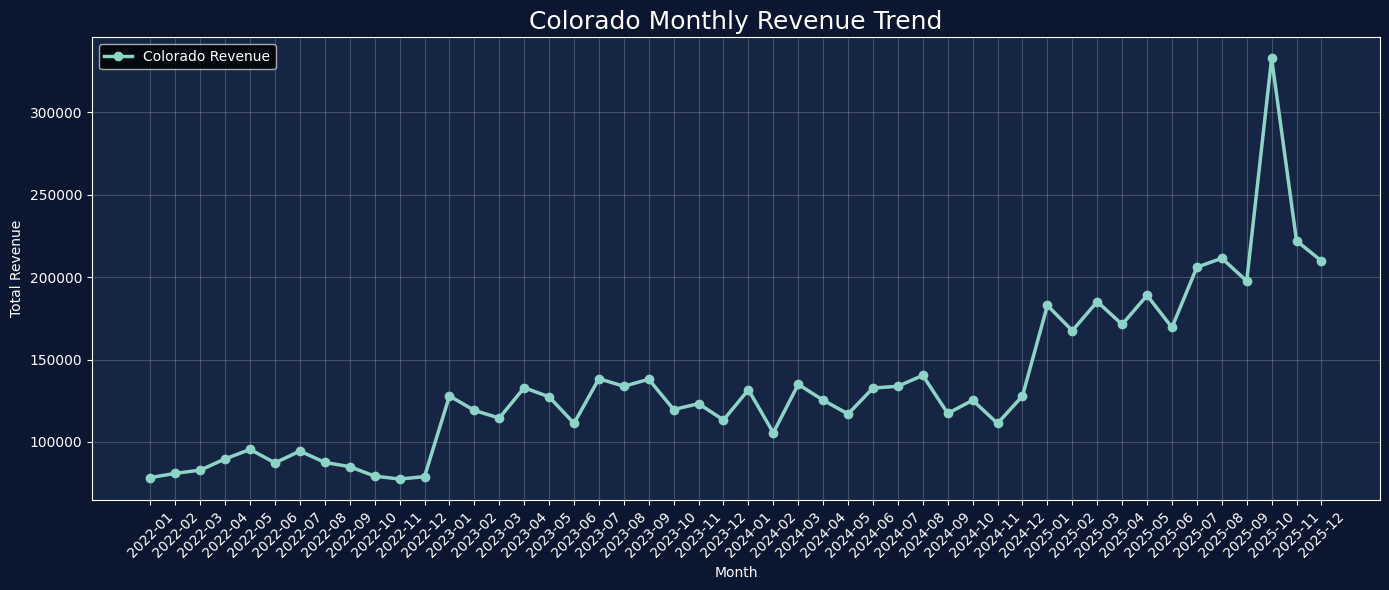

In [398]:
fig, ax = plt.subplots(figsize=(14, 6))

fig.patch.set_facecolor("#0b1730")
ax.set_facecolor("#162544")

ax.plot(colorado_monthly_revenue["Year-Month"].astype(str),colorado_monthly_revenue["Total Revenue"],marker="o",linewidth=2.5,label="Colorado Revenue")

ax.set_title("Colorado Monthly Revenue Trend", color="white", fontsize=18)
ax.set_xlabel("Month", color="white")
ax.set_ylabel("Total Revenue", color="white")

ax.tick_params(axis="x", colors="white", rotation=45)
ax.tick_params(axis="y", colors="white")

ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.savefig("colorado_monthly_revenue.png", bbox_inches="tight")
plt.show()

### Florida

In [195]:
florida_sales = completed_sales_data[completed_sales_data["State"] == "Florida"]

In [196]:
florida_monthly_revenue = (florida_sales.groupby("Year-Month")["Sale Amount"].sum().reset_index().sort_values("Year-Month").reset_index(drop=True))
florida_monthly_revenue.index += 1
florida_monthly_revenue

,Year-Month,Sale Amount
1,2022-01,48714.32
2,2022-02,46584.27
3,2022-03,54035.48
4,2022-04,49992.58
5,2022-05,58840.26
6,2022-06,49094.30
7,2022-07,57878.63
8,2022-08,48894.58
9,2022-09,43158.35
10,2022-10,49940.49


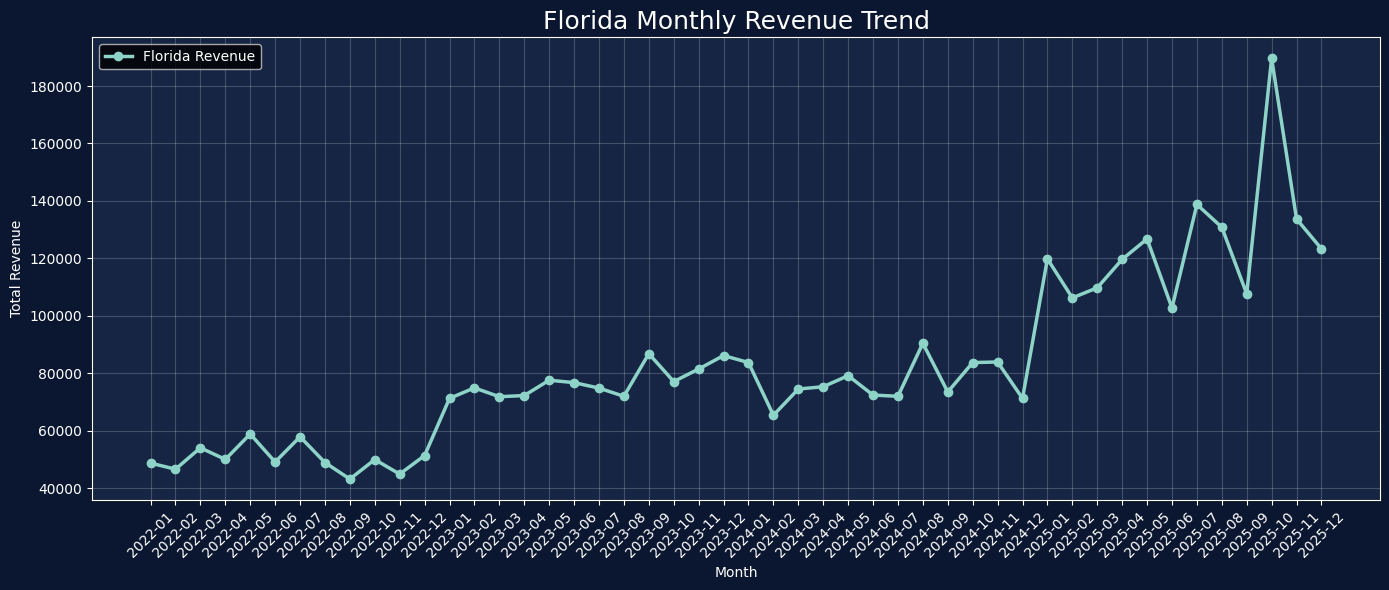

In [395]:
fig, ax = plt.subplots(figsize=(14, 6))

fig.patch.set_facecolor("#0b1730")
ax.set_facecolor("#162544")

ax.plot(florida_monthly_revenue["Year-Month"].astype(str),florida_monthly_revenue["Total Revenue"],marker="o",linewidth=2.5,label="Florida Revenue")

ax.set_title("Florida Monthly Revenue Trend", color="white", fontsize=18)
ax.set_xlabel("Month", color="white")
ax.set_ylabel("Total Revenue", color="white")

ax.tick_params(axis="x", colors="white", rotation=45)
ax.tick_params(axis="y", colors="white")

ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.savefig("florida_monthly_revenue.png", bbox_inches="tight")
plt.show()

## Store Performance Insight 

#### Colorado

In [197]:
colorado_store_performance = (colorado_sales.groupby(["Store ID", "Store Location"])["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=False).reset_index(drop=True))

In [198]:
colorado_store_performance.index += 1
colorado_store_performance["Rank"] = colorado_store_performance.index
colorado_store_performance

,Store ID,Store Location,Sale Amount,Rank
1,705,Denver,925684.89,1
2,709,Greeley,646301.23,2
3,706,Englewood,347074.83,3
4,710,Lafayette,339414.82,4
5,703,Boulder,323621.53,5
6,716,Sedalia,322694.11,6
7,701,Aurora,320318.03,7
8,708,Grand Junction,309154.46,8
9,707,Fort Collins,305159.90,9
10,704,Castle Rock,301082.30,10


In Colorado, the top-performing store was Store 705 located in Denver with total sales of $925684.89.

#### Florida

In [199]:
florida_store_performance = (florida_sales.groupby(["Store ID", "Store Location"])["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=False).reset_index(drop=True))

In [200]:
florida_store_performance.index += 1
florida_store_performance["Rank"] = florida_store_performance.index
florida_store_performance

,Store ID,Store Location,Sale Amount,Rank
1,724,Miami,623988.83,1
2,728,Tallahassee,546896.88,2
3,722,Key West,334728.32,3
4,719,Cape Canaveral,333922.55,4
5,721,Jacksonville,333495.70,5
6,727,Sebring,332965.26,6
7,729,Tampa,311158.77,7
8,720,Fort Lauderdale,305448.78,8
9,726,Orlando,299859.38,9
10,723,Lakeland,276228.02,10


In Florida, the top-performing store was Store 724 located in Miami with total sales of $623988.83.

### Hypothesis 

Stores perform best during holiday seasons because technology sales increase during those months.

Colorado

In [201]:
completed_sales_data["Category"].unique()

<StringArray>
[ 'Apparel and Merchandise',                'Textbooks',
             'Art Supplies', 'Technology & Accessories',
          'Books (General)',  'Stationery and Supplies',
                        nan]
Length: 7, dtype: str

In [202]:
colorado_tech = colorado_sales[colorado_sales["Category"] == "Technology"]

In [203]:
colorado_monthly_revenue = (colorado_sales.groupby("Year-Month")["Sale Amount"].sum().reset_index())

In [204]:
colorado_tech_monthly = (colorado_tech.groupby("Year-Month")["Sale Amount"].sum().reset_index())

In [205]:
colorado_monthly_revenue = (colorado_monthly_revenue.rename(columns={"Sale Amount": "Total Revenue"}))
colorado_tech_monthly = (colorado_tech_monthly.rename(columns={"Sale Amount": "Technology Revenue"}))

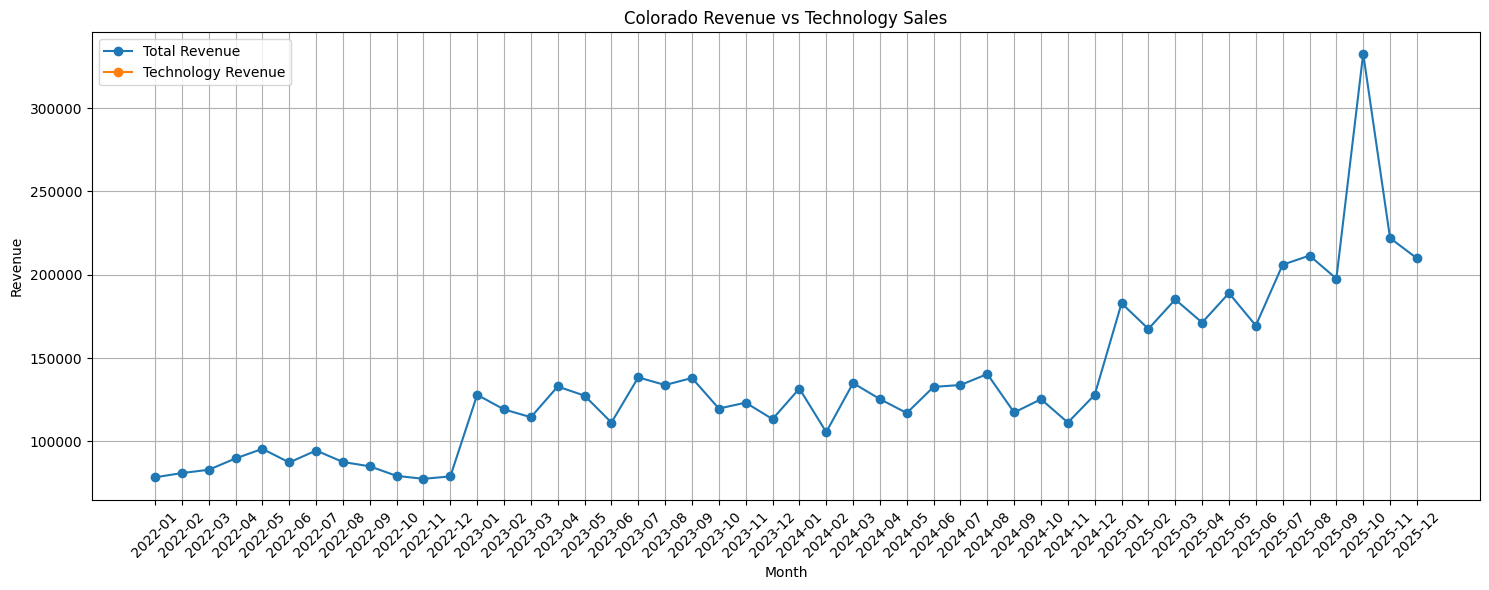

In [206]:
plt.figure(figsize=(15,6))
plt.plot(colorado_chart_data["Year-Month"].astype(str),colorado_chart_data["Total Revenue"],marker="o",label="Total Revenue")
plt.plot(colorado_chart_data["Year-Month"].astype(str),colorado_chart_data["Technology Revenue"],marker="o",label="Technology Revenue")
plt.title("Colorado Revenue vs Technology Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Florida

In [207]:
florida_tech = florida_sales[florida_sales["Category"] == "Technology"]

In [208]:
florida_tech_monthly = (florida_tech.groupby("Year-Month")["Sale Amount"].sum().reset_index())

In [209]:
florida_monthly_revenue = (florida_monthly_revenue.rename(columns={"Sale Amount": "Total Revenue"}))

In [210]:
florida_tech_monthly = (florida_tech_monthly.rename(columns={"Sale Amount": "Technology Revenue"}))

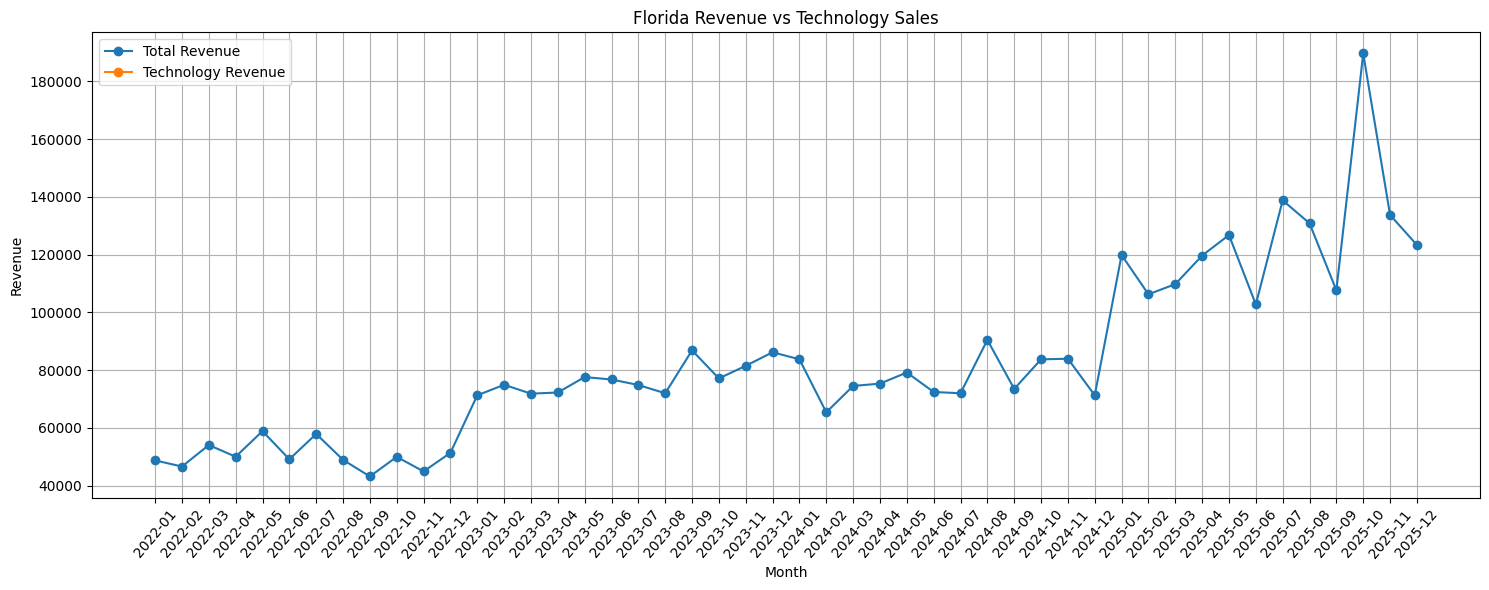

In [211]:
plt.figure(figsize=(15,6))
plt.plot(florida_chart_data["Year-Month"].astype(str),florida_chart_data["Total Revenue"],marker="o",label="Total Revenue")
plt.plot(florida_chart_data["Year-Month"].astype(str),florida_chart_data["Technology Revenue"],marker="o",label="Technology Revenue")
plt.title("Florida Revenue vs Technology Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=50)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Data combination to show comparison

In [277]:
colorado_monthly_revenue = (colorado_monthly_revenue.rename(columns={"Sale Amount": "Colorado Total Revenue"}))
colorado_tech_monthly = (colorado_tech_monthly.rename(columns={"Sale Amount": "Colorado Tech Revenue"}))

In [278]:
florida_monthly_revenue = (florida_monthly_revenue.rename(columns={"Sale Amount": "Florida Total Revenue"}))
florida_tech_monthly = (florida_tech_monthly.rename(columns={"Sale Amount": "Florida Tech Revenue"}))

In [279]:
hypothesis_sales_analysis = (colorado_monthly_revenue.merge(colorado_tech_monthly,on="Year-Month",how="left").merge(florida_monthly_revenue,on="Year-Month",how="left").merge(florida_tech_monthly,on="Year-Month",how="left"))

In [280]:
hypothesis_sales_analysis = hypothesis_sales_analysis.rename(columns={"Total Revenue_x": "Colorado Total Revenue","Technology Revenue_x": "Colorado Tech Revenue","Total Revenue_y": "Florida Total Revenue","Technology Revenue_y": "Florida Tech Revenue"})

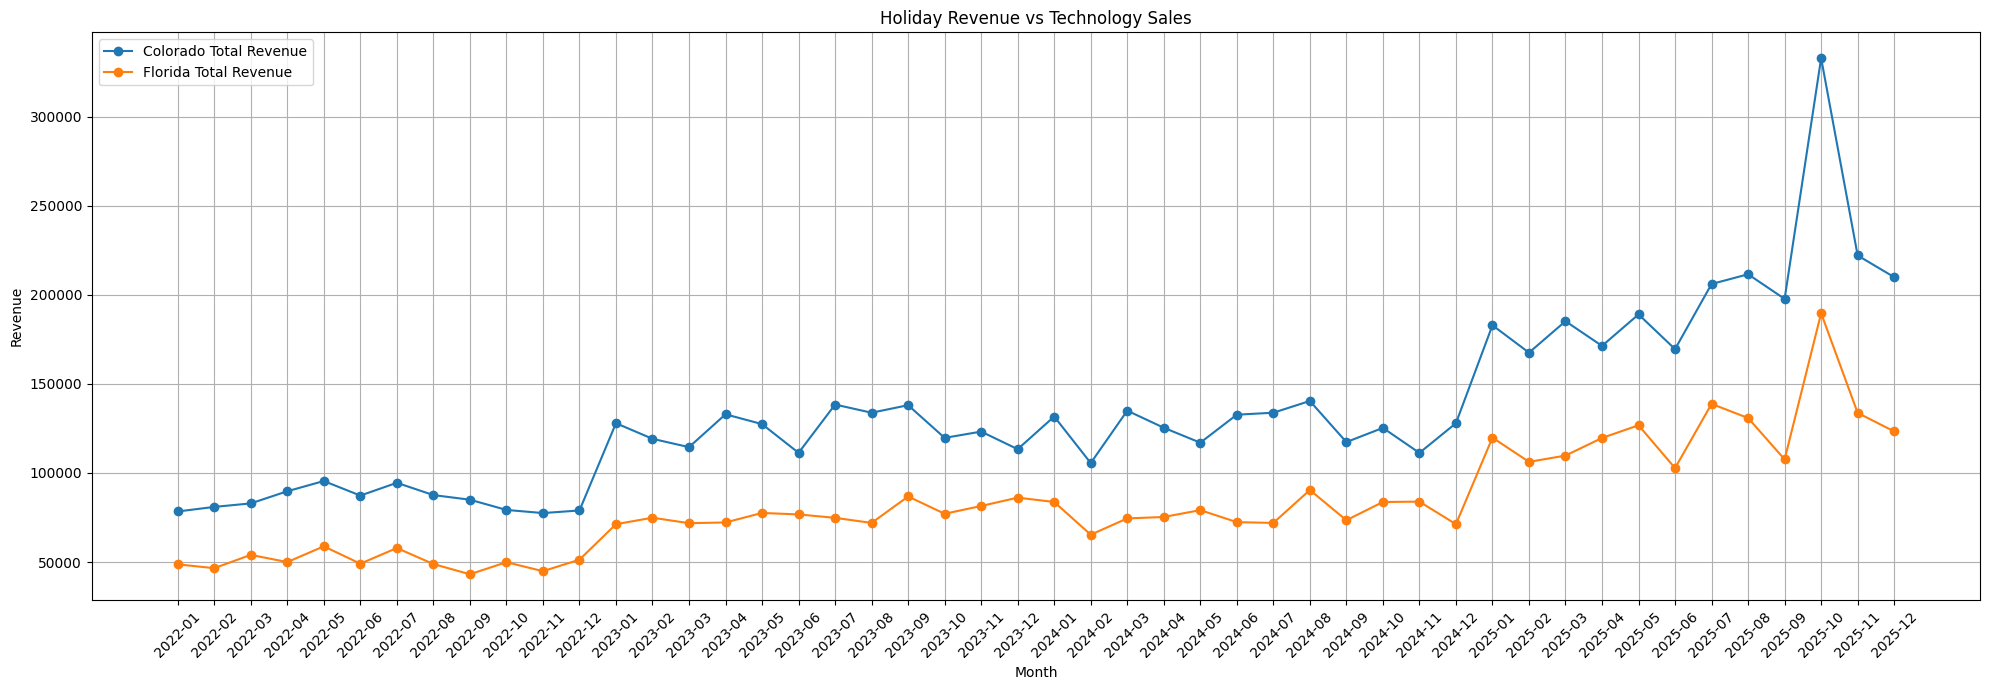

In [281]:
plt.figure(figsize=(20,7))
plt.plot(hypothesis_sales_analysis["Year-Month"].astype(str),hypothesis_sales_analysis["Colorado Total Revenue"],marker="o",label="Colorado Total Revenue")
plt.plot(hypothesis_sales_analysis["Year-Month"].astype(str),hypothesis_sales_analysis["Florida Total Revenue"],marker="o",label="Florida Total Revenue")
plt.title("Holiday Revenue vs Technology Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Customers Insight

In [241]:
colorado_sales = completed_sales_data[completed_sales_data["State"] == "Colorado"]

In [255]:
colorado_top_customers = colorado_top_customers.rename(columns={"cust_id": "CustomerID","name": "Name","Sale Amount": "Total Revenue"})
colorado_top_customers["CustomerID"] = (colorado_top_customers["CustomerID"].astype(int))
colorado_top_customers.head(10)

,CustomerID,Name,Total Revenue
1,245,Gloria Mendoza,7855.66
2,375,C.J. Cregg,5016.67
3,380,Abbey Bartlet,4617.31
4,242,Lorna Morello,4381.15
5,279,Adrian Veidt,4365.77
6,3,Monica Geller,4173.74
7,209,Vivian Banks,4125.13
8,464,Kima Greggs,4096.06
9,189,Abby Whelan,3927.14
10,128,Sonny Corinthos,3842.41


Florida

In [243]:
florida_sales = completed_sales_data[completed_sales_data["State"] == "Florida"]

In [254]:
florida_top_customers = florida_top_customers.rename(columns={"cust_id": "CustomerID","name": "Name","Sale Amount": "Total Revenue"})
florida_top_customers["CustomerID"] = (florida_top_customers["CustomerID"].astype(int))
florida_top_customers.head(10)

,CustomerID,Name,Total Revenue
1,47,Stanley H.,4954.99
2,259,Todd Chavez,4549.16
3,190,Huck,4427.90
4,335,John Locke,3631.94
5,164,Dr. Ray Flemming,3535.88
6,418,Ernie,3387.58
7,56,Leslie Knope,3355.68
8,143,Billy Abbott,3334.54
9,215,Lisa W.,3240.71
10,212,Geoffrey,3225.15


A small group of repeat rewards customers contributed a lot of total sales revenue. In Colorado, the top customers spent over$7,000. 

In Florida multiple customers spent over $4,000.

These findings suggest that loyalty program members play an important role in overall revenue performance. 
Customer retention strategies should be one of our large focuses.

## Transaction & Product Insight

### Transactions by category

Colorado

In [286]:
colorado_category_transactions = (colorado_sales.groupby(["Year-Month", "Category"]).size().reset_index(name="Transactions"))
colorado_category_transactions.index +=1
colorado_category_transactions

,Year-Month,Category,Transactions
1,2022-01,Apparel and Merchandise,108
2,2022-01,Art Supplies,98
3,2022-01,Books (General),43
4,2022-01,Stationery and Supplies,112
5,2022-01,Technology & Accessories,126
...,...,...,...
284,2025-12,Art Supplies,276
285,2025-12,Books (General),102
286,2025-12,Stationery and Supplies,293
287,2025-12,Technology & Accessories,344


Florida

In [287]:
florida_category_transactions = (florida_sales.groupby(["Year-Month", "Category"]).size().reset_index(name="Transactions"))
florida_category_transactions.index += 1
florida_category_transactions

,Year-Month,Category,Transactions
1,2022-01,Apparel and Merchandise,66
2,2022-01,Art Supplies,80
3,2022-01,Books (General),20
4,2022-01,Stationery and Supplies,69
5,2022-01,Technology & Accessories,75
...,...,...,...
284,2025-12,Art Supplies,160
285,2025-12,Books (General),71
286,2025-12,Stationery and Supplies,178
287,2025-12,Technology & Accessories,192


### Monthly Revenue By Category

Colorado

In [304]:
colorado_category_revenue = (colorado_sales.groupby(["Year-Month", "Category"])["Sale Amount"].sum().reset_index(name="Total Revenue"))
colorado_category_revenue

,Year-Month,Category,Total Revenue
0,2022-01,Apparel and Merchandise,3632.40
1,2022-01,Art Supplies,2635.79
2,2022-01,Books (General),959.78
3,2022-01,Stationery and Supplies,1229.66
4,2022-01,Technology & Accessories,51086.31
...,...,...,...
283,2025-12,Art Supplies,8728.44
284,2025-12,Books (General),3320.63
285,2025-12,Stationery and Supplies,2953.44
286,2025-12,Technology & Accessories,154975.51


In [305]:
colorado_top_categories = (colorado_sales.groupby("Category")["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=False))
colorado_top_categories["Rank"] = range(1, len(colorado_top_categories) + 1)
colorado_top_categories

,Category,Sale Amount,Rank
4,Technology & Accessories,4554123.47,1
5,Textbooks,1113146.79,2
0,Apparel and Merchandise,299559.51,3
1,Art Supplies,276139.10,4
2,Books (General),107407.42,5
3,Stationery and Supplies,98482.62,6


Flordia

In [291]:
florida_category_revenue = (florida_sales.groupby(["Year-Month", "Category"])["Sale Amount"].sum().reset_index(name="Total Revenue"))
florida_category_revenue

,Year-Month,Category,Total Revenue
0,2022-01,Apparel and Merchandise,1980.69
1,2022-01,Art Supplies,2484.65
2,2022-01,Books (General),553.10
3,2022-01,Stationery and Supplies,669.58
4,2022-01,Technology & Accessories,32658.69
...,...,...,...
283,2025-12,Art Supplies,4598.35
284,2025-12,Books (General),2275.34
285,2025-12,Stationery and Supplies,1807.28
286,2025-12,Technology & Accessories,93257.11


In [306]:
florida_top_categories = (florida_sales.groupby("Category")["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=False))
florida_top_categories["Rank"] = range(1, len(florida_top_categories) + 1)
florida_top_categories

,Category,Sale Amount,Rank
4,Technology & Accessories,2764161.11,1
5,Textbooks,706789.57,2
0,Apparel and Merchandise,180626.02,3
1,Art Supplies,166929.81,4
2,Books (General),70124.49,5
3,Stationery and Supplies,61114.75,6


In both Colorado and Florida technology products generated the highest total sales. These categories also maintained strong transaction volume, meaning both high popularity and high profitability.

Some lower performing products showed consistent transaction activity but lower total revenue, which may indicate opportunities for pricing improvements, bundled promotions, or a huge one is targeted marketing campaigns.

The findings suggest that future growth opportunities may exist through increased promotion of high-performing technology products, especially during peak seasonal shopping months when customer demand is strongest.

In [310]:
average_transaction = (colorado_sales.groupby("Category")["Sale Amount"].mean().reset_index(name="Average Transaction Value"))
average_transaction.index+=1
average_transaction

,Category,Average Transaction Value
1,Apparel and Merchandise,32.550202
2,Art Supplies,31.075748
3,Books (General),28.764708
4,Stationery and Supplies,10.073918
5,Technology & Accessories,464.422136
6,Textbooks,173.171560


# Marketing Recommendation

## 1. Holiday Revenue Trend

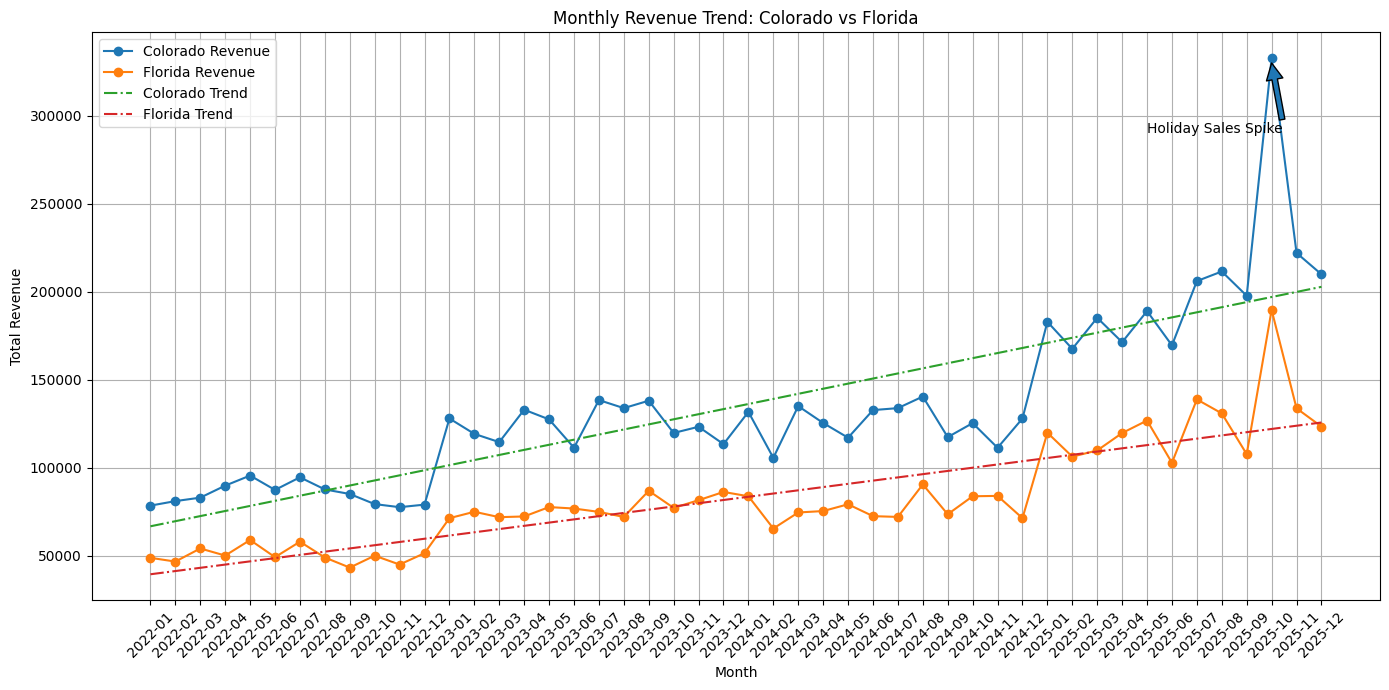

In [371]:
plt.figure(figsize=(14, 7))
x = np.arange(len(holiday_sales_analysis))
plt.plot(x,holiday_sales_analysis["Colorado Total Revenue"],marker="o",label="Colorado Revenue")
plt.plot(x,holiday_sales_analysis["Florida Total Revenue"],marker="o",label="Florida Revenue")

colorado_trend = np.polyfit(x,holiday_sales_analysis["Colorado Total Revenue"],1)
plt.plot(x,np.poly1d(colorado_trend)(x),linestyle="-.",label="Colorado Trend")


florida_trend = np.polyfit(x,holiday_sales_analysis["Florida Total Revenue"],1)
plt.plot(x,np.poly1d(florida_trend)(x),linestyle="-.",label="Florida Trend")
plt.title("Monthly Revenue Trend: Colorado vs Florida")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(x,holiday_sales_analysis["Year-Month"].astype(str),rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.annotate("Holiday Sales Spike",xy=(45, 330000),xytext=(40, 290000),arrowprops=dict())
plt.savefig("holiday_trend.png", bbox_inches="tight")
plt.show()

## 2. Product Category Performance

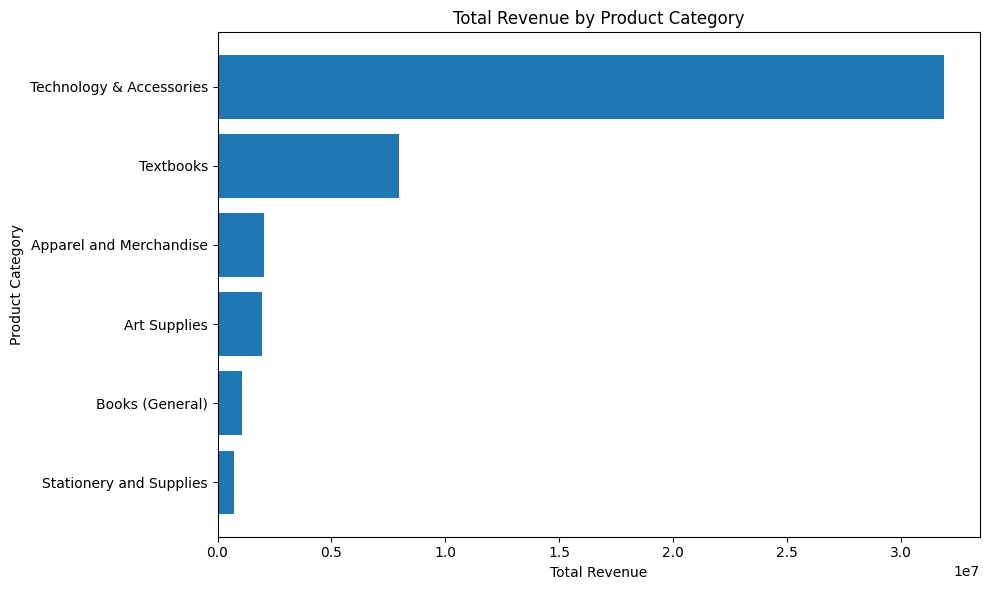

In [341]:
category_performance = (completed_sales_data.groupby("Category")["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=True))
plt.figure(figsize=(10, 6))
plt.barh(category_performance["Category"],category_performance["Sale Amount"])
plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

## 3. Rewards Program Opportunity

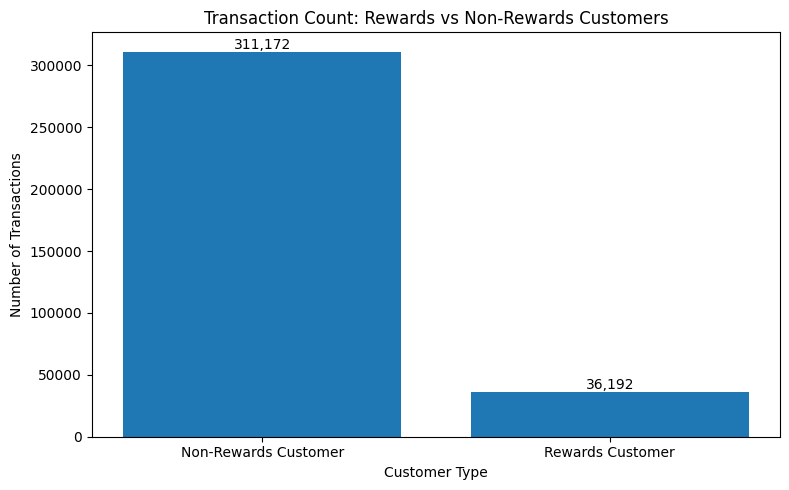

In [342]:
customer_type_transactions = (
    completed_sales_data
    .groupby("Customer Type")
    .size()
    .reset_index(name="Transactions")
)

plt.figure(figsize=(8, 5))

plt.bar(
    customer_type_transactions["Customer Type"],
    customer_type_transactions["Transactions"]
)

plt.title("Transaction Count: Rewards vs Non-Rewards Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Transactions")

for i, value in enumerate(customer_type_transactions["Transactions"]):
    plt.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

This chart shows that non-rewards customers account for a much larger number of transactions than rewards customers. This suggests that the rewards program is not capturing a large portion of the customer base yet. The opportunity is not just to reward existing rewards members, but to convert more non-rewards customers into the program.

In [343]:
top_rewards_customers = (
    completed_sales_data[
        completed_sales_data["Customer Type"] == "Rewards Customer"
    ]
    .groupby(["cust_id", "name"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values("Sale Amount", ascending=False)
    .head(10)
)

top_rewards_customers = top_rewards_customers.rename(
    columns={
        "cust_id": "CustomerID",
        "name": "Name",
        "Sale Amount": "Total Revenue"
    }
)

top_rewards_customers["CustomerID"] = top_rewards_customers["CustomerID"].astype(int)

top_rewards_customers

,CustomerID,Name,Total Revenue
244,245,Gloria Mendoza,17534.76
73,74,Ben Chang,17494.39
179,180,Cole Brown,17440.65
46,47,Stanley H.,16532.80
374,375,C.J. Cregg,16520.45
279,280,Cal Abar,16453.48
241,242,Lorna Morello,15984.11
408,409,Gerri Kellman,15959.27
98,99,Trent Lane,15847.67
399,400,K. McClanahan,15625.56


In [401]:
top_non_rewards_transactions = (completed_sales_data[completed_sales_data["Customer Type"] == "Non-Rewards Customer"][["Transaction Date", "Store Location", "State", "Category", "Product", "Sale Amount"]].sort_values("Sale Amount", ascending=False).head(10))

top_non_rewards_transactions = top_non_rewards_transactions.rename(columns={"Sale Amount": "Transaction Amount"})

top_non_rewards_transactions

,Transaction Date,Store Location,State,Category,Product,Transaction Amount
119509,2023-10-11,Cape Canaveral,Florida,Technology & Accessories,MSI Creator Z16,1763.7
186988,2024-08-13,Greenville,South Carolina,Technology & Accessories,MSI Creator Z16,1763.7
80540,2023-04-15,Cedar Park,Texas,Technology & Accessories,MSI Creator Z16,1763.7
329340,2025-11-06,Hartford,Connecticut,Technology & Accessories,MSI Creator Z16,1763.7
70026,2023-02-26,North Harford,Maryland,Technology & Accessories,MSI Creator Z16,1763.7
69966,2023-02-26,Aurora,Colorado,Technology & Accessories,MSI Creator Z16,1763.7
205038,2024-11-04,New Bedford,Massachusetts,Technology & Accessories,MSI Creator Z16,1763.7
327918,2025-11-02,North Harford,Maryland,Technology & Accessories,MSI Creator Z16,1763.7
329438,2025-11-07,Parker,Colorado,Technology & Accessories,MSI Creator Z16,1763.7
130817,2023-12-01,Leominster,Massachusetts,Technology & Accessories,MSI Creator Z16,1763.7


The top rewards customer table shows that rewards members can generate strong repeat revenue. The non-rewards table shows that high-value purchases are also happening outside the rewards program. Since those non-rewards transactions are not connected to a customer profile, the business loses an opportunity to track repeat behavior, target customers directly, and build long-term loyalty.

This supports the need for a stronger rewards program that encourages more customers to identify themselves at checkout.

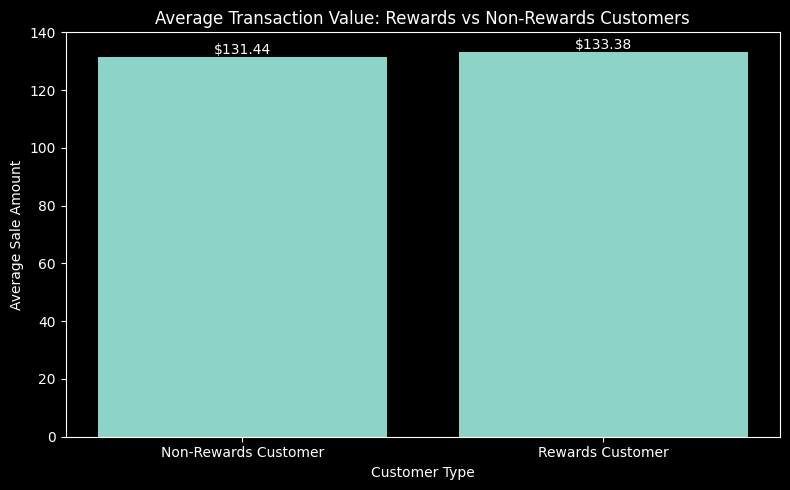

In [400]:
rewards_avg_sale = (completed_sales_data.groupby("Customer Type")["Sale Amount"].mean().reset_index())

plt.figure(figsize=(8, 5))

plt.bar(rewards_avg_sale["Customer Type"],rewards_avg_sale["Sale Amount"])

plt.title("Average Transaction Value: Rewards vs Non-Rewards Customers")
plt.xlabel("Customer Type")
plt.ylabel("Average Sale Amount")

for i, value in enumerate(rewards_avg_sale["Sale Amount"]):
    plt.text(i, value, f"${value:,.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

The average transaction value for rewards and non-rewards customers is very similar. This suggests that rewards customers are not dramatically outspending non-rewards customers on each individual purchase. However, it also shows that non-rewards customers are already valuable shoppers.

The business opportunity is to convert more of these non-rewards customers into rewards members. If EmporiUm can bring more high-value non-rewards shoppers into the rewards program, the company can improve retention, track customer behavior more effectively, and use targeted incentives to guide customers toward lower-performing product categories.

Marketing Recommendation

Based on the analysis, I recommend that EmporiUm focus next quarter’s marketing strategy on three areas: holiday technology promotions, year-round support for lower-performing categories, and growth of the rewards program.

The revenue trend analysis showed that sales increased during holiday shopping periods, especially in Colorado. Technology & Accessories was the strongest-performing category and appeared to drive many of the largest revenue increases. Because of this, EmporiUm should begin promoting top-selling technology products before the holiday season to maximize customer demand and revenue.

The category analysis also showed that products such as Stationery and Supplies, Books, and Art Supplies generated lower revenue throughout the year. These categories may benefit from year-round promotions, bundle offers, discounts, and cross-promotions with stronger products.

Finally, the rewards analysis showed that many transactions came from non-rewards customers, even though rewards and non-rewards customers had similar average transaction values. This suggests that the company has an opportunity to increase customer retention and loyalty by expanding the rewards program and offering bonus points or redemption incentives tied to lower-performing categories.

Overall, EmporiUm should use high-performing technology products to drive seasonal revenue while using rewards-based incentives and targeted promotions to strengthen weaker categories and improve long-term customer engagement.


## Dashboard Codes

1. Total Revenue

In [360]:
total_revenue = completed_sales_data["Sale Amount"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $45,728,774.86


-----------------------------------------------------

2. Total Transactions

In [361]:
total_transactions = len(completed_sales_data)

print(f"Total Transactions: {total_transactions:,}")

Total Transactions: 347,364


-----------------------------------------------------

3. Top Territory

In [362]:
top_territory = completed_sales_data.groupby("State")["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=False).head(1))

top_territory

,State,Sale Amount
4,Maryland,11539422.39


-----------------------------------------------------

4. Top Product Category

In [363]:
top_category = (completed_sales_data.groupby("Category")["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=False).head(1))

top_category

,Category,Sale Amount
4,Technology & Accessories,31891406.58


-----------------------------------------------------

5. Revenue by Territory

In [364]:
revenue_by_territory = (completed_sales_data.groupby("State")["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=False))

revenue_by_territory

,State,Sale Amount
4,Maryland,11539422.39
0,Colorado,6465821.91
5,Massachusetts,5778202.52
6,New Jersey,5218545.28
7,New York,4364809.91
2,Florida,3960266.80
9,Texas,3444621.55
1,Connecticut,2410901.11
3,Maine,1892183.23
8,South Carolina,654000.16


-----------------------------------------------------

6. Transactions by Customer Type

In [365]:
customer_type_transactions = (completed_sales_data.groupby("Customer Type").size().reset_index(name="Transactions"))

customer_type_transactions

,Customer Type,Transactions
0,Non-Rewards Customer,311172
1,Rewards Customer,36192


-----------------------------------------------------

7. Average Transaction Value by Customer Type

In [366]:
avg_transaction_by_customer_type = (completed_sales_data.groupby("Customer Type")["Sale Amount"].mean().reset_index(name="Average Transaction Value"))

avg_transaction_by_customer_type

,Customer Type,Average Transaction Value
0,Non-Rewards Customer,131.443889
1,Rewards Customer,133.375246


-----------------------------------------------------

8. Product Category Revenue

In [367]:
category_performance = (completed_sales_data.groupby("Category")["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=False))

category_performance

,Category,Sale Amount
4,Technology & Accessories,31891406.58
5,Textbooks,7961357.21
0,Apparel and Merchandise,2043382.60
1,Art Supplies,1938358.84
2,Books (General),1070718.51
3,Stationery and Supplies,702088.52


-----------------------------------------------------

9. Best Month by Territory

In [368]:
best_month_by_territory = (completed_sales_data.groupby(["State", "Year-Month"])["Sale Amount"].sum().reset_index().sort_values(["State", "Sale Amount"], ascending=[True, False]).groupby("State").head(1))

best_month_by_territory

,State,Year-Month,Sale Amount
45,Colorado,2025-10,332771.12
93,Connecticut,2025-10,116752.04
141,Florida,2025-10,189635.49
189,Maine,2025-10,94192.76
237,Maryland,2025-10,362276.15
285,Massachusetts,2025-10,279661.56
333,New Jersey,2025-10,252453.51
381,New York,2025-10,186812.36
427,South Carolina,2025-08,34532.89
477,Texas,2025-10,170362.01


-----------------------------------------------------

10. Top Rewards Customers

In [369]:
top_rewards_customers = (completed_sales_datacompleted_sales_data["Customer Type"] == "Rewards Customer"].groupby(["cust_id", "name"])["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=False).head(10))

top_rewards_customers = top_rewards_customers.rename(columns={"cust_id": "CustomerID","name": "Name","Sale Amount": "Total Revenue"})

top_rewards_customers["CustomerID"] = top_rewards_customers["CustomerID"].astype(int)

top_rewards_customers

,CustomerID,Name,Total Revenue
244,245,Gloria Mendoza,17534.76
73,74,Ben Chang,17494.39
179,180,Cole Brown,17440.65
46,47,Stanley H.,16532.80
374,375,C.J. Cregg,16520.45
279,280,Cal Abar,16453.48
241,242,Lorna Morello,15984.11
408,409,Gerri Kellman,15959.27
98,99,Trent Lane,15847.67
399,400,K. McClanahan,15625.56


-----------------------------------------------------

11. Monthly Revenue Trend Data

In [370]:
monthly_revenue_dashboard = (completed_sales_data.groupby(["Year-Month", "State"])["Sale Amount"].sum().reset_index())

monthly_revenue_dashboard

,Year-Month,State,Sale Amount
0,2022-01,Colorado,78395.85
1,2022-01,Connecticut,30083.34
2,2022-01,Florida,48714.32
3,2022-01,Maine,15837.31
4,2022-01,Maryland,191777.84
...,...,...,...
475,2025-12,Massachusetts,187907.97
476,2025-12,New Jersey,172535.07
477,2025-12,New York,129225.84
478,2025-12,South Carolina,22740.22


-----------------------------------------------------

In [373]:
completed_sales_data["Customer Type"] = np.where(completed_sales_data["RewardsID"].isnull(),"Non-Rewards Customer","Rewards Customer")

In [374]:
rewards_participation = (completed_sales_data.groupby("Customer Type").size().reset_index(name="Transactions"))

rewards_participation

,Customer Type,Transactions
0,Non-Rewards Customer,311172
1,Rewards Customer,36192


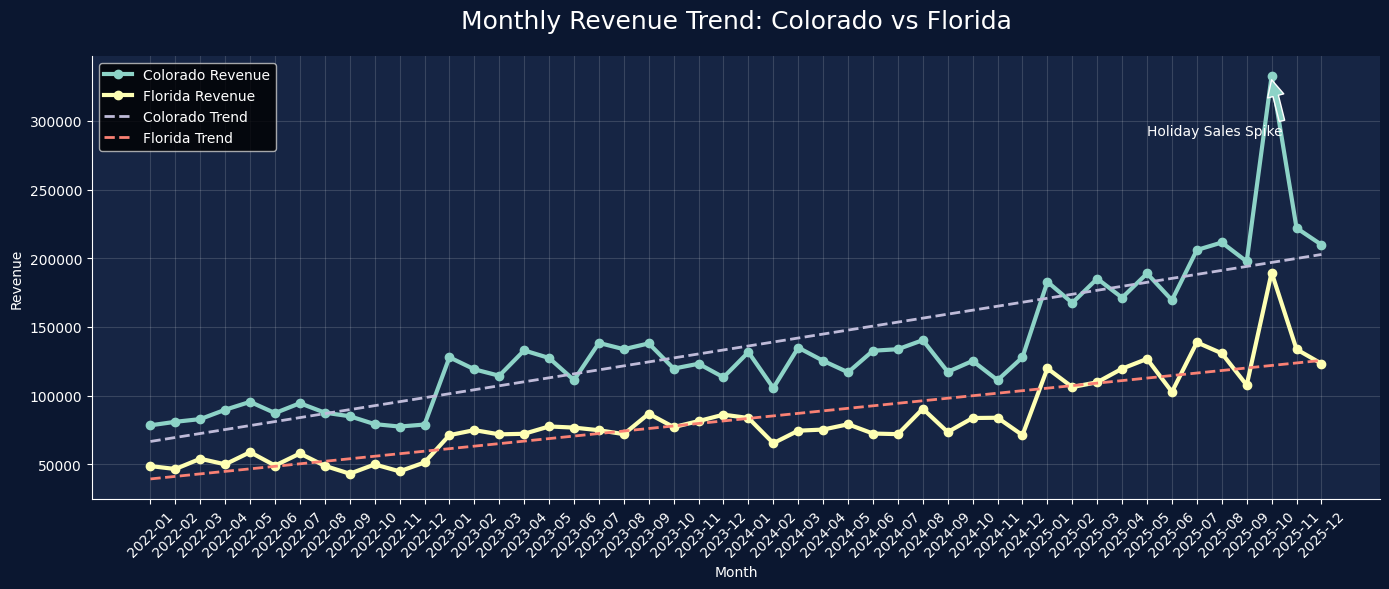

In [399]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(14,6))

fig.patch.set_facecolor("#0b1730")

ax.set_facecolor("#162544")

x = np.arange(len(holiday_sales_analysis))

ax.plot(x,holiday_sales_analysis["Colorado Total Revenue"],marker="o",linewidth=3,label="Colorado Revenue")

ax.plot(x,holiday_sales_analysis["Florida Total Revenue"],marker="o",linewidth=3,label="Florida Revenue")

colorado_trend = np.polyfit(x,holiday_sales_analysis["Colorado Total Revenue"],1)

florida_trend = np.polyfit(x,holiday_sales_analysis["Florida Total Revenue"],1)

ax.plot(x,np.poly1d(colorado_trend)(x),linestyle="--",linewidth=2,label="Colorado Trend")

ax.plot(x,np.poly1d(florida_trend)(x),linestyle="--",linewidth=2,label="Florida Trend")

ax.set_title("Monthly Revenue Trend: Colorado vs Florida",fontsize=18,pad=20,color="white")

ax.set_xlabel("Month", color="white")
ax.set_ylabel("Revenue", color="white")

ax.set_xticks(x)

ax.set_xticklabels(holiday_sales_analysis["Year-Month"],rotation=45,color="white")


ax.grid(alpha=0.15,color="white")

legend = ax.legend()

for text in legend.get_texts():
    text.set_color("white")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.annotate("Holiday Sales Spike",xy=(45, 330000),xytext=(40, 290000),arrowprops=dict())

plt.show()

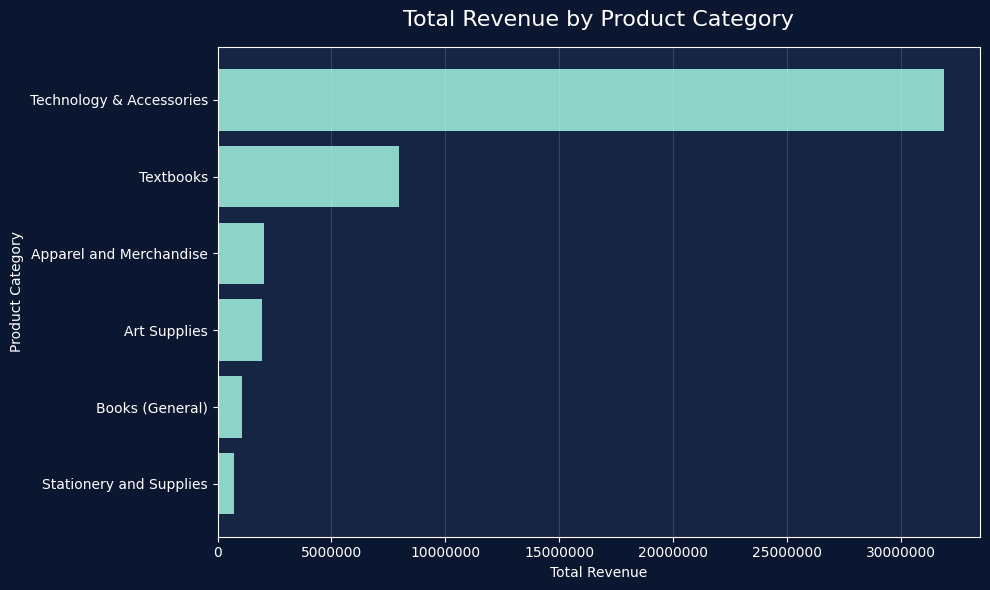

In [379]:
category_performance = (completed_sales_data.groupby("Category")["Sale Amount"].sum().reset_index().sort_values("Sale Amount", ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#0b1730")
ax.set_facecolor("#162544")

ax.barh(category_performance["Category"],category_performance["Sale Amount"])

ax.set_title("Total Revenue by Product Category",color="white",fontsize=16,pad=15)

ax.set_xlabel("Total Revenue", color="white")
ax.set_ylabel("Product Category", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="x", alpha=0.15)

ax.ticklabel_format(style="plain", axis="x")

plt.tight_layout()


plt.show()